In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Reading the data

data = pd.read_csv('../../data/raw/marketing_campaign.csv', sep="\t")

data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Duplicates: None 

Dt_Customer stored as string (needs datetime conversion in data processing)

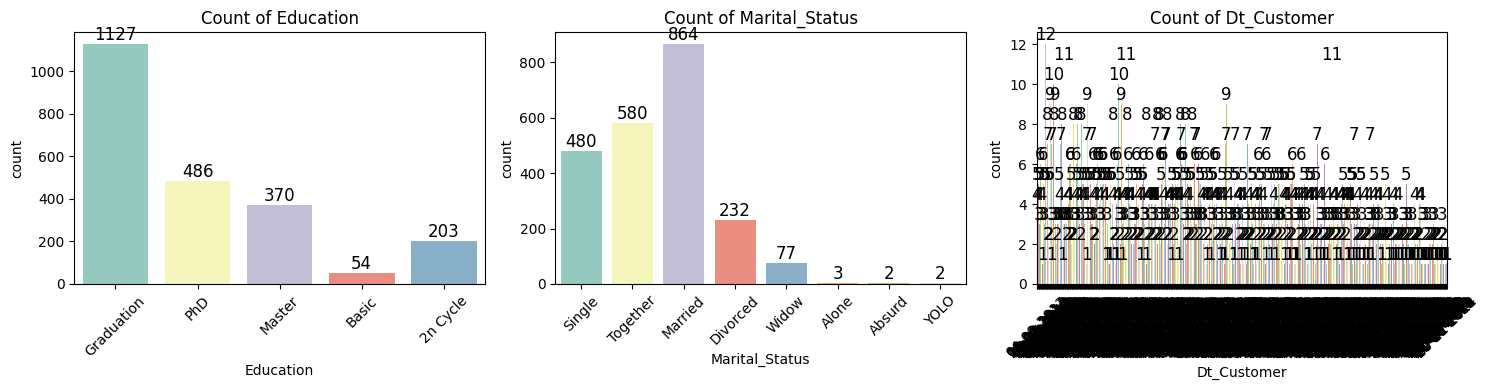

In [7]:
# Checking distribution of categorical variables

str_columns = data.select_dtypes(include='str').columns
fig, axes = plt.subplots(1, len(str_columns), figsize=(5*len(str_columns), 4))

if len(str_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, str_columns):
    sns.countplot(x=col, data=data,hue=col, ax=ax, palette="Set3")
    
    # Add counts
    for p in ax.patches:
        height = int(p.get_height())
        ax.annotate(f'{height}', 
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=12)
    
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Education (5 categories) • Most common: Graduation (1127 customers, ~50%) 
Marital Status (8 categories) • Most common: Married (864 customers)

In [8]:
# Add some additional features that might be useful and might give insights

# calculating Age of the customer
data['Age'] = 2026 - data['Year_Birth']

# calculating total spend by the customer over all the categories
data['Total_Spend'] = (data['MntWines'] + data['MntFruits'] 
                            + data['MntMeatProducts'] + data['MntFishProducts'] 
                            + data['MntSweetProducts'] + data['MntGoldProds'] )
data['Total_Purchase'] = (data['NumDealsPurchases'] + data['NumWebPurchases'] + 
                          data['NumCatalogPurchases'] + data['NumStorePurchases'])

# Calculating Total number of children 
data['Children_at_home'] = data['Kidhome'] + data['Teenhome']

# we can see in above bar charts that Marital_status has few categories which has small numbers 
# so consolidating them 
data["Living_With"] = data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

data['Education'] = data['Education'].replace({'Basic':'Undergraduate', '2n Cycle':'Undergraduate', 'Graduation':'Graduate', 'Master':'Postgraduate', 'PhD':'PhD'})

# Total family members inclusing children
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2}) + data["Children_at_home"]

data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spend,Total_Purchase,Children_at_home,Living_With,Family_Size
0,5524,1957,Graduate,Single,58138.0,0,0,04-09-2012,58,635,...,0,3,11,1,69,1617,25,0,Alone,1
1,2174,1954,Graduate,Single,46344.0,1,1,08-03-2014,38,11,...,0,3,11,0,72,27,6,2,Alone,3
2,4141,1965,Graduate,Together,71613.0,0,0,21-08-2013,26,426,...,0,3,11,0,61,776,21,0,Partner,2
3,6182,1984,Graduate,Together,26646.0,1,0,10-02-2014,26,11,...,0,3,11,0,42,53,8,1,Partner,3
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,3,11,0,45,422,19,1,Partner,3


In [ ]:
# Min and max
data['Total_Spend'].min(), data['Total_Spend'].max()
# 25th, 50th (median), 75th percentiles
data['Total_Spend'].quantile([0.25, 0.50, 0.75])




0.25      68.75
0.50     396.00
0.75    1045.50
Name: Total_Spend, dtype: float64

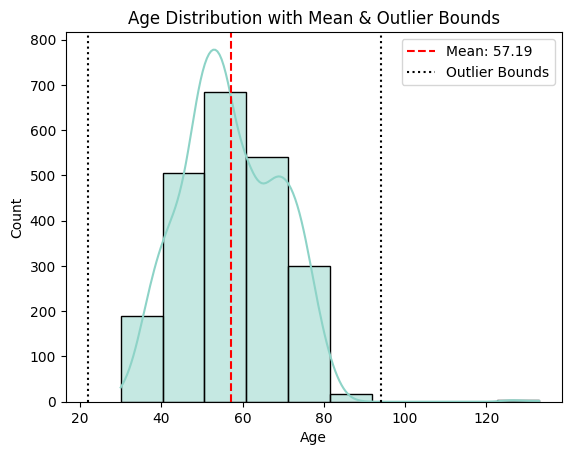

In [ ]:
# Checking Age distribution
# Example: split by actual spending amounts (unequal group sizes)
bins = [0, 68.75, 396.00, 1045.50, data['Total_Spending'].max() + 1]  # adjust to your data
labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']

data['Spending_Segment'] = pd.cut(data['Total_Spending'], bins=bins, labels=labels)

# Now group sizes will be unequal
data['Spending_Segment'].value_counts()

# Calculate mean
mean_age = data["Age"].mean()

# IQR for outliers
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Plot
sns.set_palette("Set3")
sns.histplot(data["Age"], bins=10, kde=True)

# Mean line
plt.axvline(mean_age, color="red", linestyle="--", label=f"Mean: {mean_age:.2f}")

# Outlier boundaries
plt.axvline(lower_bound, color="black", linestyle=":", label="Outlier Bounds")
plt.axvline(upper_bound, color="black", linestyle=":")

plt.legend()
plt.title("Age Distribution with Mean & Outlier Bounds")
plt.show()

Age (Year_Birth) • Mean age is 57.19 and we can see some outliers as well

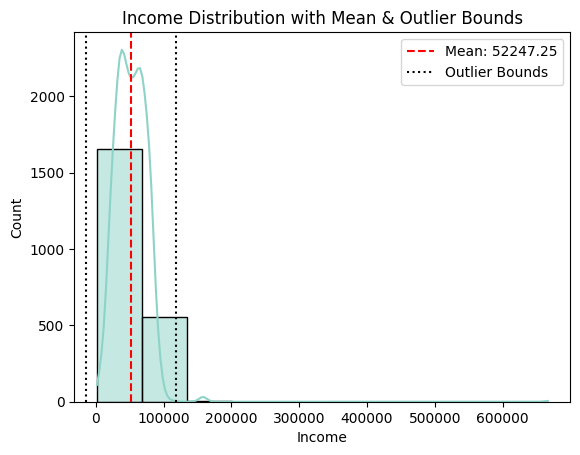

In [12]:
# Checking Income distribution

# Calculate mean
mean_income = data["Income"].mean()

# IQR for outliers
Q1 = data["Income"].quantile(0.25)
Q3 = data["Income"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Plot
sns.set_palette("Set3")
sns.histplot(data["Income"], bins=10, kde=True)

# Mean line
plt.axvline(mean_income, color="red", linestyle="--", label=f"Mean: {mean_income:.2f}")

# Outlier boundaries
plt.axvline(lower_bound, color="black", linestyle=":", label="Outlier Bounds")
plt.axvline(upper_bound, color="black", linestyle=":")

plt.legend()
plt.title("Income Distribution with Mean & Outlier Bounds")
plt.show()

Income Distribution • Mean: 51,381 • Max: 666,666 
Strong right skew due to high-income outliers.

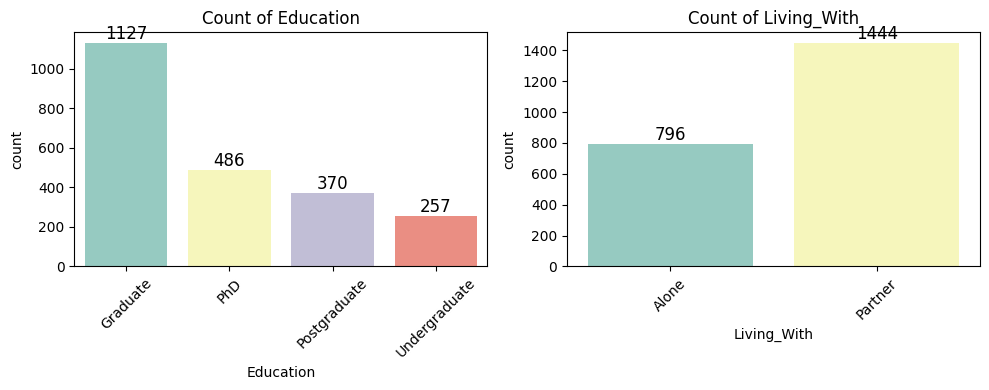

In [13]:
# Updated categorical variables 
str_columns = ['Education','Living_With']
fig, axes = plt.subplots(1, len(str_columns), figsize=(5*len(str_columns), 4))

if len(str_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, str_columns):
    sns.countplot(x=col, data=data,hue=col, ax=ax, palette="Set3")
    
    # Add counts
    for p in ax.patches:
        height = int(p.get_height())
        ax.annotate(f'{height}', 
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=12)
    
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# checking descriptive statistics for some useful numerical variables
# Looking at Age - there is a max value of 133 which is outlier

# Columns to analyze
num_cols = (["Income", "Age", "Total_Spend","Children_at_home","Recency",
         "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
          "NumStorePurchases", "NumWebVisitsMonth","MntWines","MntFruits","MntMeatProducts",
          "MntFishProducts","MntSweetProducts","MntGoldProds",
            "AcceptedCmp3" , "AcceptedCmp4", "AcceptedCmp5" ,"AcceptedCmp1", "AcceptedCmp2",
          "Complain", "Response"])

# Compute descriptive stats
numeric_analysis = data[num_cols].describe().T

# Add skewness and kurtosis
numeric_analysis['skewness'] = data[num_cols].skew()
numeric_analysis['kurtosis'] = data[num_cols].kurtosis()

# Round all numbers to 2 decimal points
numeric_analysis = numeric_analysis.round(2)

print(numeric_analysis)

                      count      mean       std     min       25%      50%  \
Income               2216.0  52247.25  25173.08  1730.0  35303.00  51381.5   
Age                  2240.0     57.19     11.98    30.0     49.00     56.0   
Total_Spend          2240.0    605.80    602.25     5.0     68.75    396.0   
Children_at_home     2240.0      0.95      0.75     0.0      0.00      1.0   
Recency              2240.0     49.11     28.96     0.0     24.00     49.0   
NumDealsPurchases    2240.0      2.33      1.93     0.0      1.00      2.0   
NumWebPurchases      2240.0      4.08      2.78     0.0      2.00      4.0   
NumCatalogPurchases  2240.0      2.66      2.92     0.0      0.00      2.0   
NumStorePurchases    2240.0      5.79      3.25     0.0      3.00      5.0   
NumWebVisitsMonth    2240.0      5.32      2.43     0.0      3.00      6.0   
MntWines             2240.0    303.94    336.60     0.0     23.75    173.5   
MntFruits            2240.0     26.30     39.77     0.0      1.0

/var/folders/1k/dx565qq97k9gvljw3b64llt80000gn/T/ipykernel_94466/3486670117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data[col], ax=axes[i],palette="Set3")
/var/folders/1k/dx565qq97k9gvljw3b64llt80000gn/T/ipykernel_94466/3486670117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data[col], ax=axes[i],palette="Set3")
/var/folders/1k/dx565qq97k9gvljw3b64llt80000gn/T/ipykernel_94466/3486670117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data[col], ax=axes[i],palette="Set3")
/var/folders/1k/dx565qq97k9gvljw3b64llt8

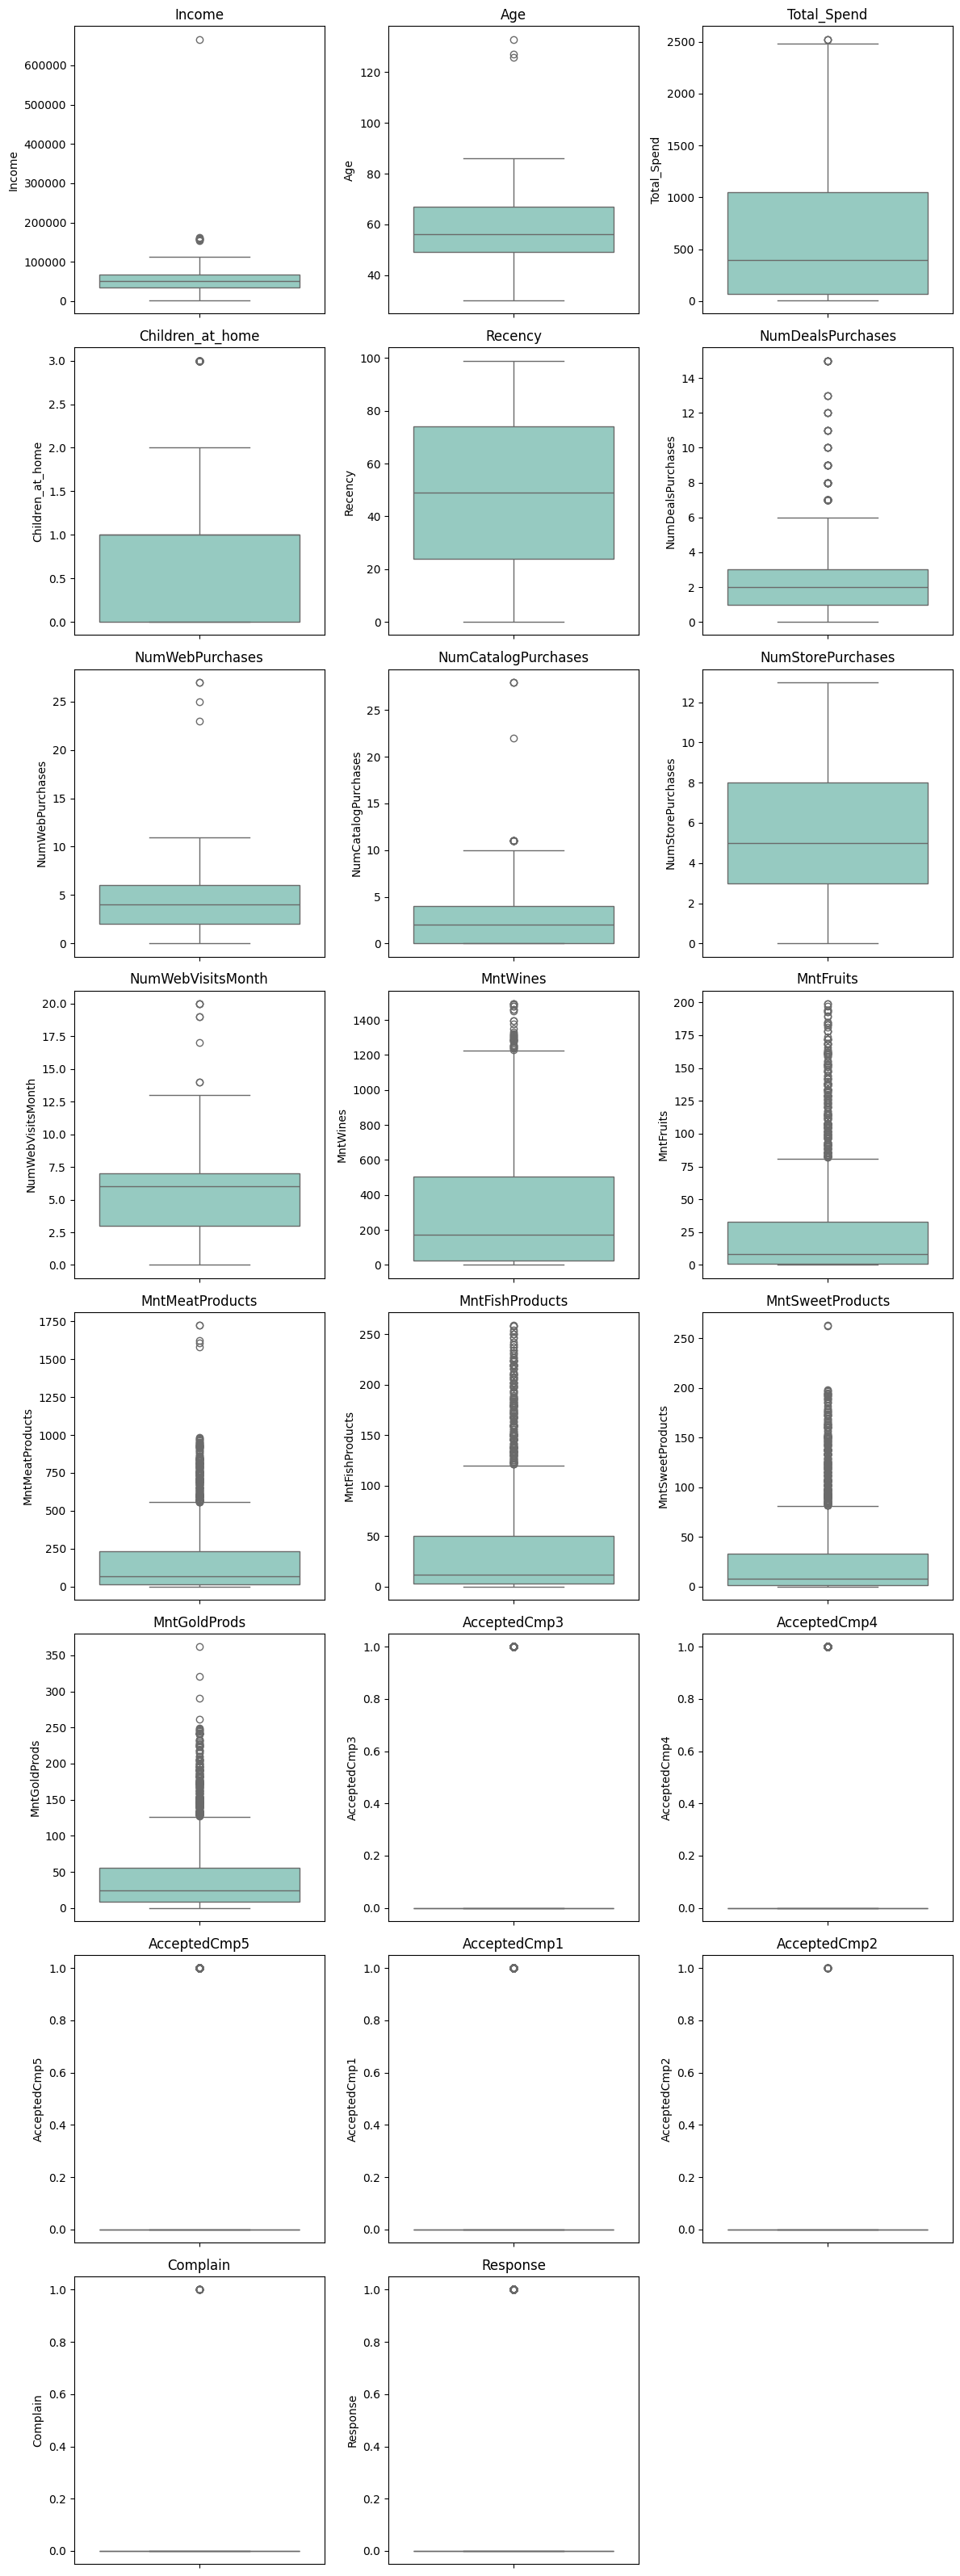

In [15]:
# Checking for outliers - based on the results we have few outliers that we need to fix

# Determine grid layout
cols_per_row = 3  # number of subplots per row
n_rows = int(np.ceil(len(num_cols) / cols_per_row))

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row*4, n_rows*4))
axes = axes.flatten()  # flatten for easy looping

# Loop through columns
for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i],palette="Set3")
    axes[i].set_title(col)

# Remove any extra empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

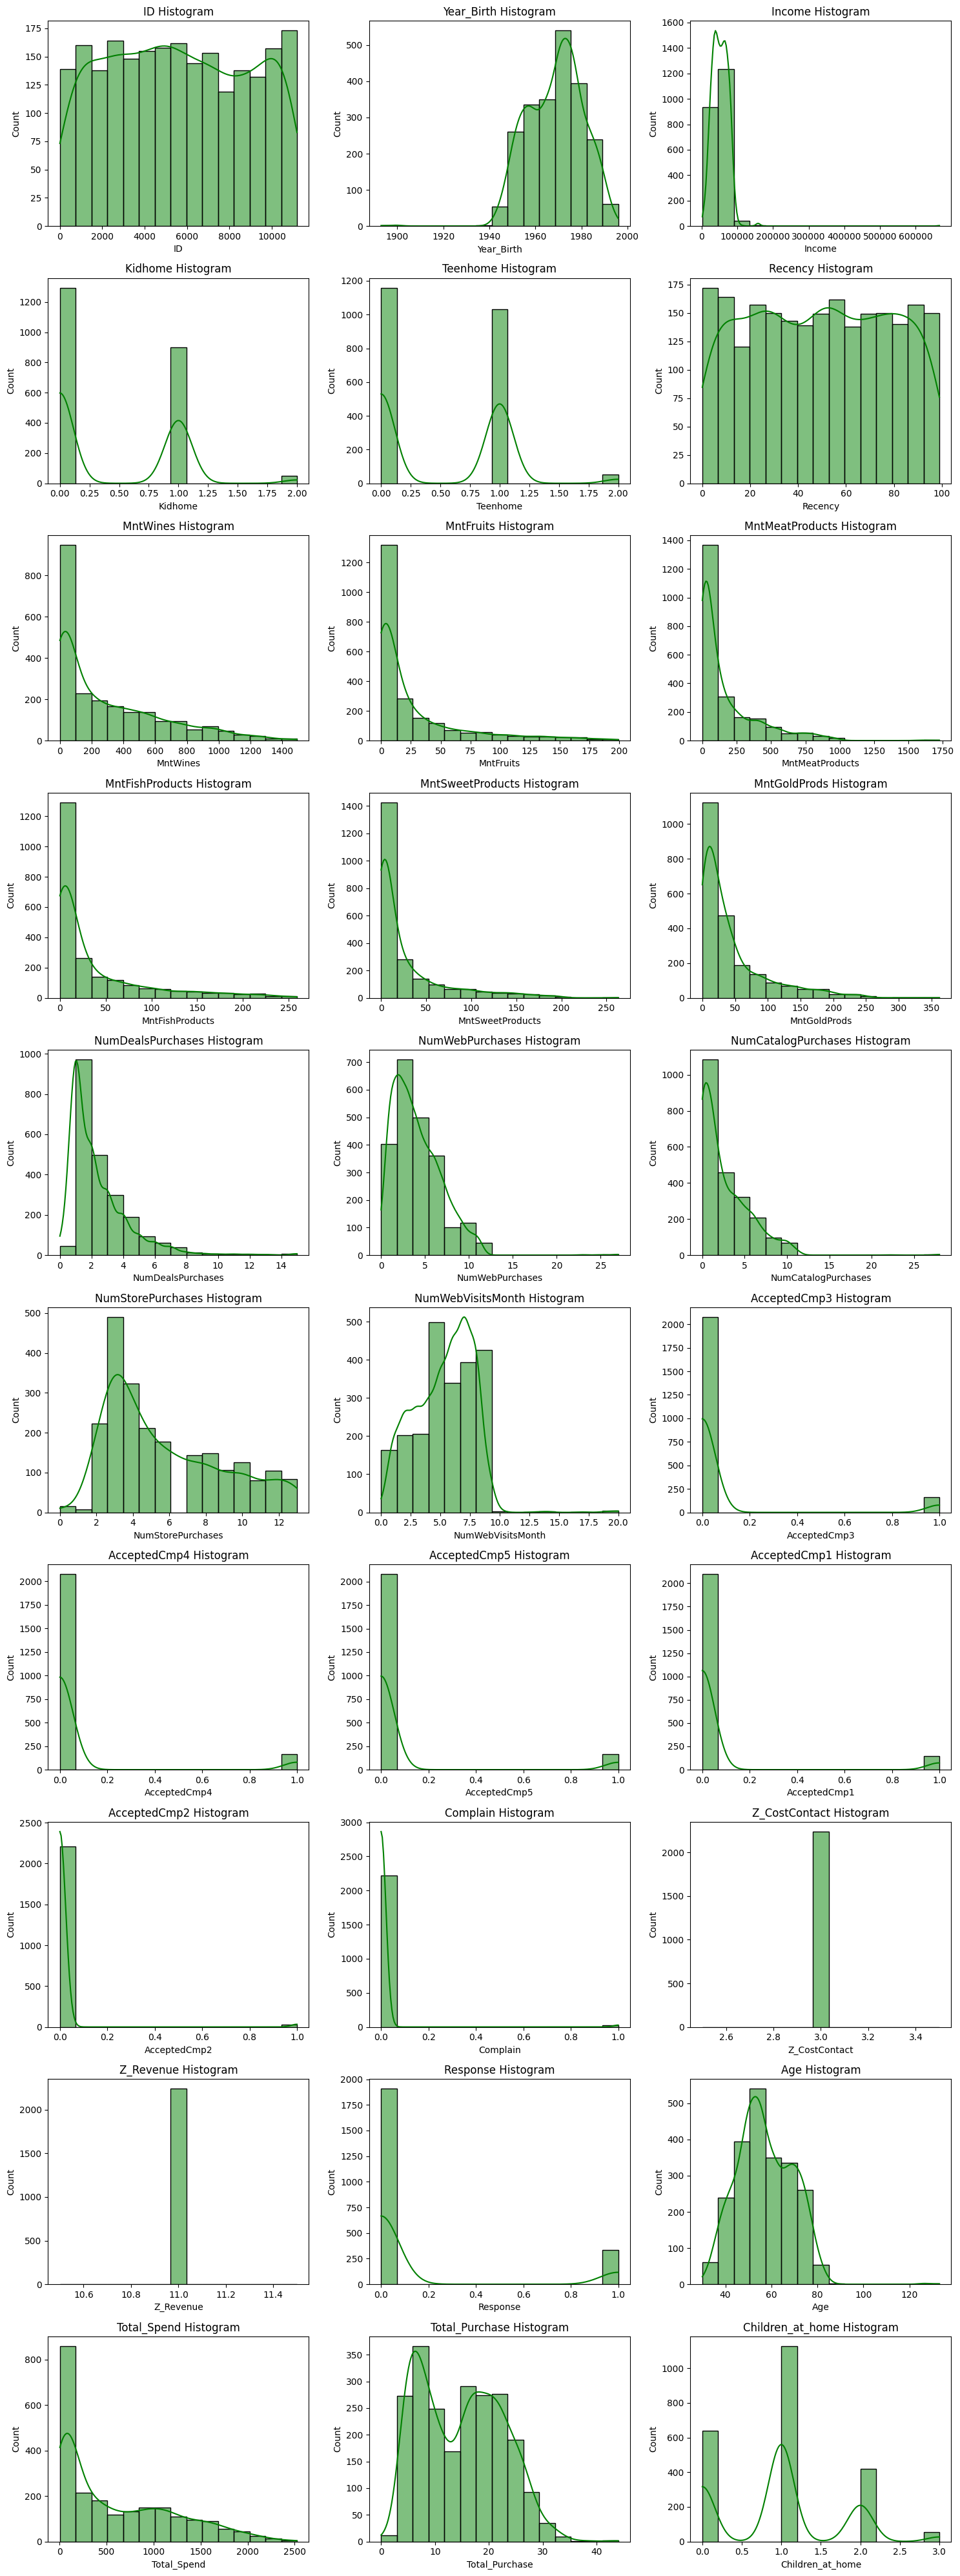

In [16]:
# Plot histograms for all numeric columns to check for distribution 

numeric_cols = data.select_dtypes(include=np.number).columns

# Determine layout
n_cols_per_row = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols_per_row))

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(n_cols_per_row*5, n_rows*4))
axes = axes.flatten()  # flatten for easy looping

# Loop through numeric columns
for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], bins=15, kde=True, ax=axes[i], color="green")
    axes[i].set_title(f"{col} Histogram")

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Spending, Income, purchase variables are highly skewed with large max values → likely require scaling.
Z_CostContact = 3 (constant) & Z_Revenue = 11 (constant) These provide no predictive value and should be removed during preprocessing.

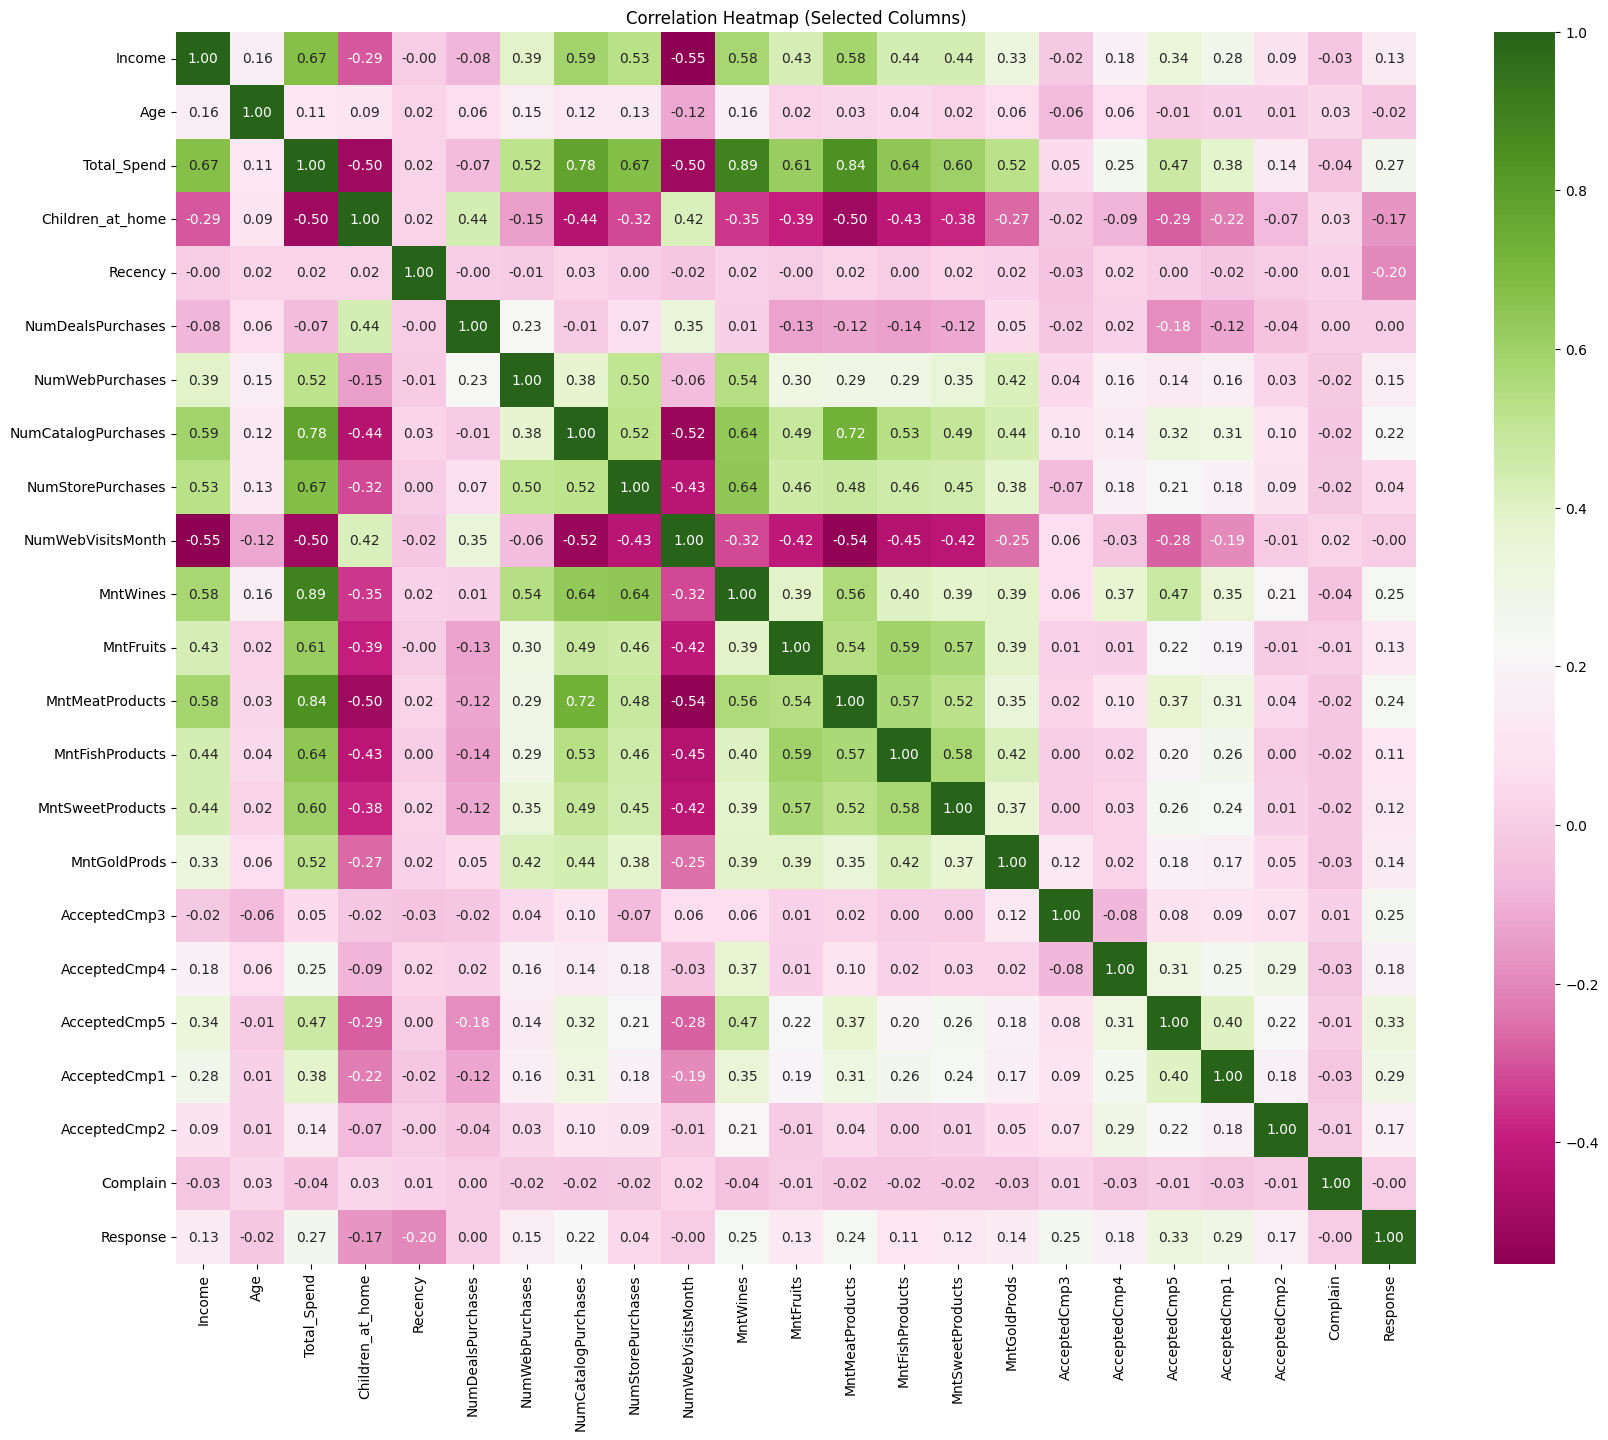

In [17]:

# Columns to include in correlation
cols_corr = (["Income", "Age", "Total_Spend","Children_at_home","Recency",
         "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
          "NumStorePurchases", "NumWebVisitsMonth","MntWines","MntFruits","MntMeatProducts",
          "MntFishProducts","MntSweetProducts","MntGoldProds",
            "AcceptedCmp3" , "AcceptedCmp4", "AcceptedCmp5" ,"AcceptedCmp1", "AcceptedCmp2",
          "Complain", "Response"])

# Compute correlation for selected columns
corr = data[cols_corr].corr()

# Plot heatmap
plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PiYG")
plt.title("Correlation Heatmap (Selected Columns)")
plt.show()

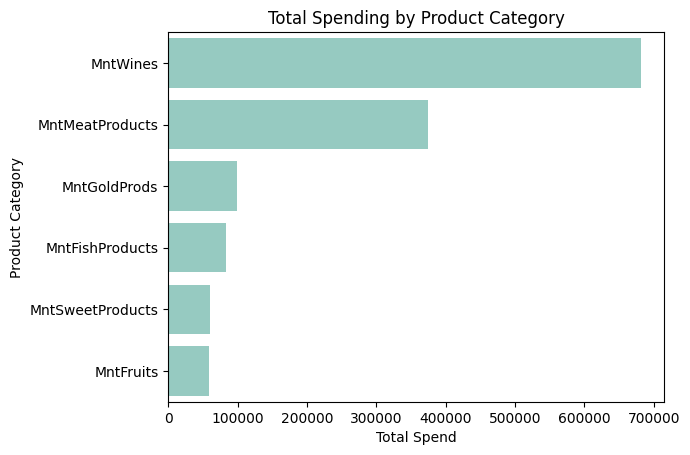

In [18]:
# Spending behaviour by products

product_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

product_totals = data[product_cols].sum().sort_values(ascending=False)

sns.set_palette("Set3")
sns.barplot(x=product_totals.values, y=product_totals.index)

plt.title("Total Spending by Product Category")
plt.xlabel("Total Spend")
plt.ylabel("Product Category")
plt.show()

Spending Behavior (Product Categories) : Customers spend significantly more on Wines and Meat compared to other products.

/var/folders/1k/dx565qq97k9gvljw3b64llt80000gn/T/ipykernel_94466/109118624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Children_at_home", y="Total_Purchase", palette="Set3")


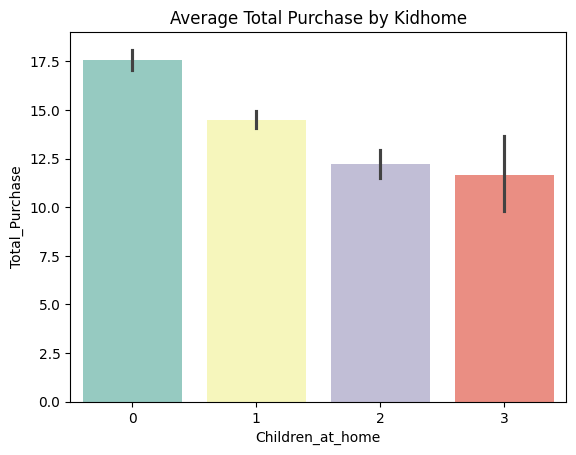

In [19]:
# Average Total purchases per childern at home
sns.barplot(data=data, x="Children_at_home", y="Total_Purchase", palette="Set3")

plt.title("Average Total Purchase by Kidhome")
plt.show()

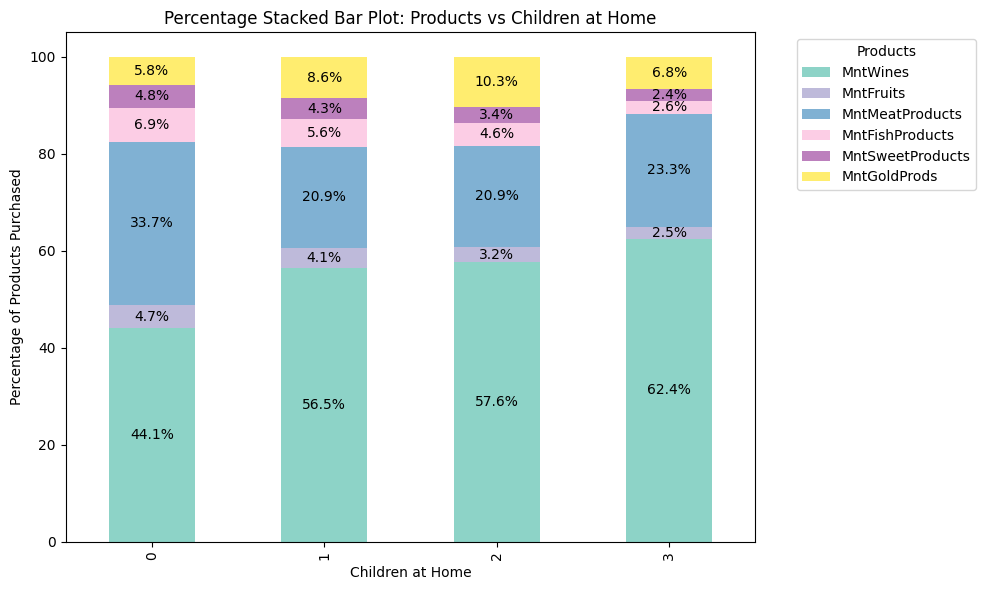

In [20]:
# Checking products Vs Number of childern at home

# Columns representing products
products = ["MntWines","MntFruits","MntMeatProducts",
          "MntFishProducts","MntSweetProducts","MntGoldProds"]

# Aggregate: sum of each product by number of children
agg = data.groupby("Children_at_home")[products].sum()

# Convert to percentages row-wise
agg_pct = agg.div(agg.sum(axis=1), axis=0) * 100

# Plot stacked bars
ax = agg_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set3')

# Add percentage labels on each segment
for i, child in enumerate(agg_pct.index):
    bottom = 0
    for prod in products:
        value = agg_pct.loc[child, prod]
        if value > 0:  # display only if > 0%
            ax.text(i, bottom + value/2, f"{value:.1f}%", ha='center', va='center', fontsize=10, color='black')
        bottom += value

plt.title("Percentage Stacked Bar Plot: Products vs Children at Home")
plt.xlabel("Children at Home")
plt.ylabel("Percentage of Products Purchased")
plt.legend(title="Products", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


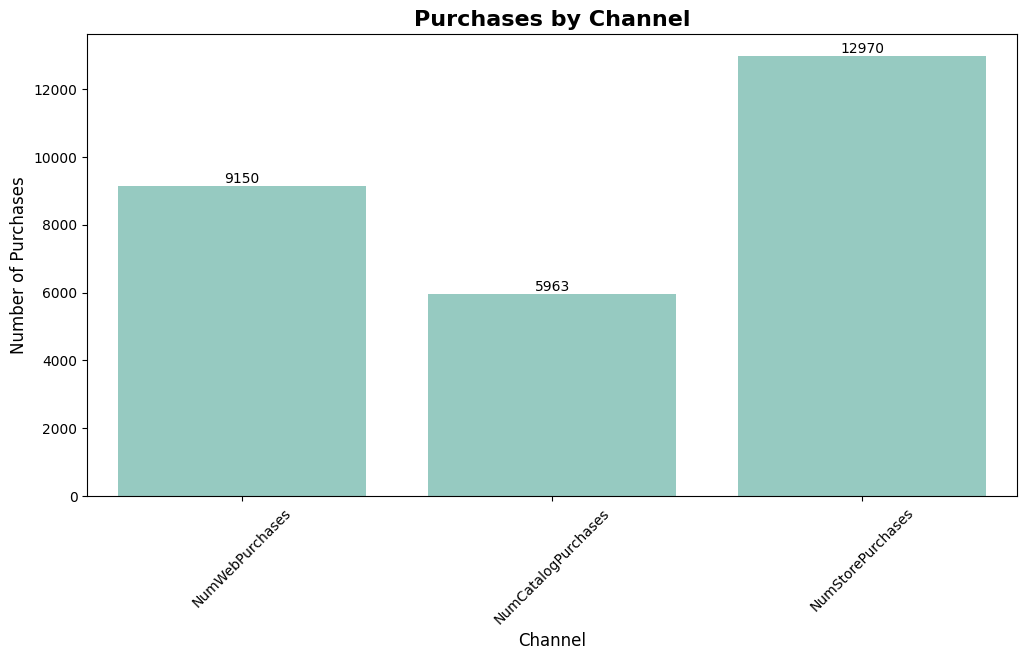

In [21]:
# checking purchase channels

sns.set_palette("Set3")
purchase_columns = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
palette = sns.color_palette("Set3")

# Aggregate total purchases per channel
total_purchases = data[purchase_columns].sum().reset_index()
total_purchases.columns = ["Channel", "TotalPurchases"]

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="Channel", 
    y="TotalPurchases", 
    data=total_purchases
)

# Add numbers on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,  # center of the bar
        y=height + 0.5,                  # slightly above the bar
        s=int(height),                    # convert to integer
        ha='center', 
        va='bottom',
        fontsize=10
    )

plt.title('Purchases by Channel', fontsize=16, fontweight='bold')
plt.ylabel('Number of Purchases', fontsize=12)
plt.xlabel('Channel', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()


Customers purcahse more in store, followed by web purchase and catalog purchase

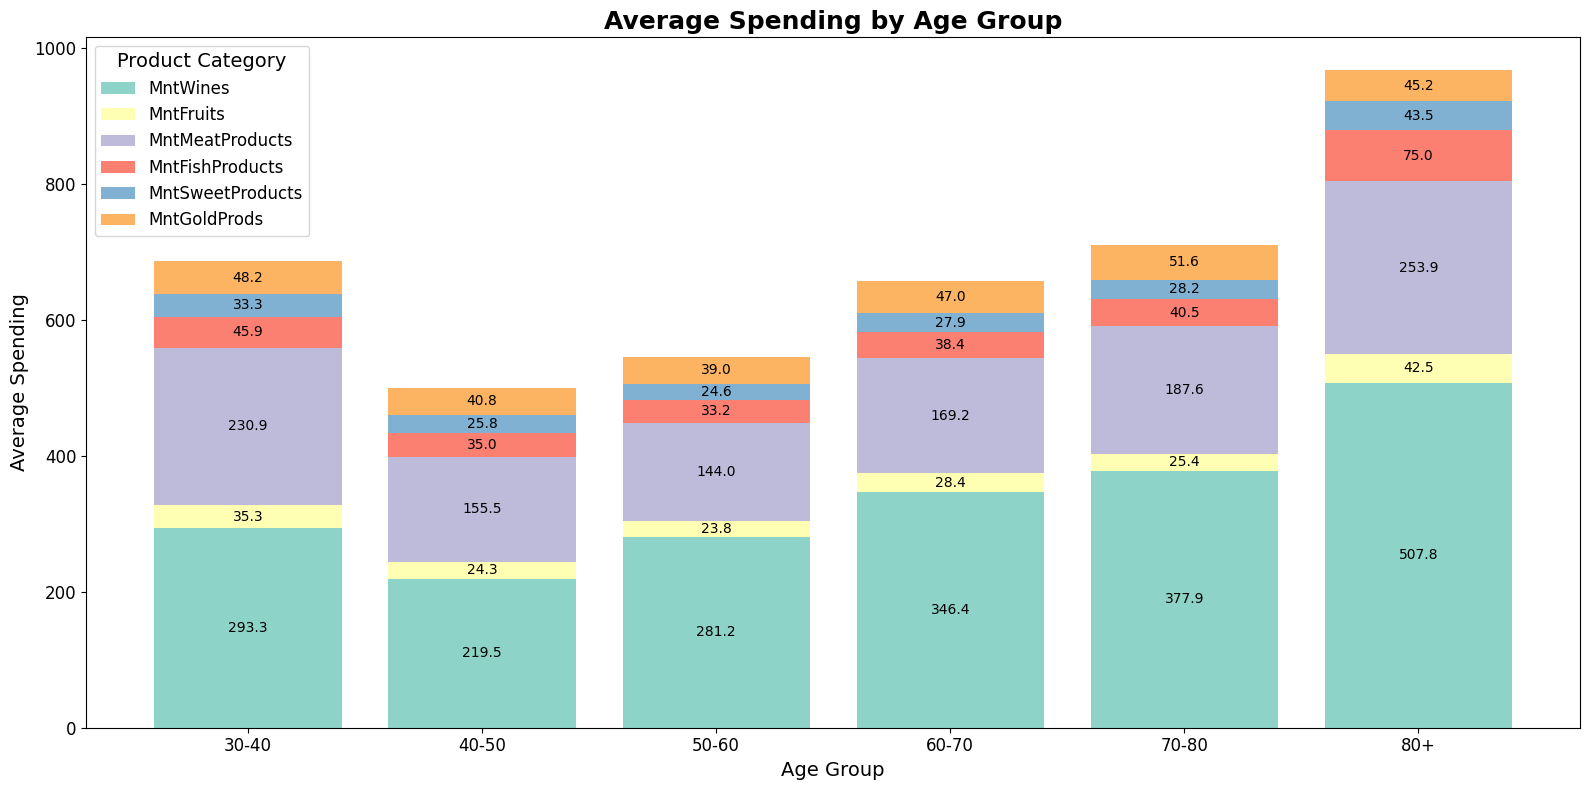

In [22]:
# spending by age group

palette = sns.color_palette("Set3")

# Create age groups
age_bins = [20, 30, 40, 50, 60, 70, 80, 100]
data['AgeGroup'] = pd.cut(
    data['Age'], 
    bins=age_bins, 
    labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+'], 
    right=False
)

# Average spending by age group
spending_by_age = data.groupby('AgeGroup', observed=True)[products].mean()

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

bottom = np.zeros(len(spending_by_age))
for i, product in enumerate(products):
    ax.bar(
        spending_by_age.index, 
        spending_by_age[product], 
        bottom=bottom, 
        color=palette[i], 
        label=product
    )
    bottom += spending_by_age[product].values  # update bottom for next product

# Add numbers on top of each segment
for i, age_group in enumerate(spending_by_age.index):
    cumulative = 0
    for j, product in enumerate(products):
        value = spending_by_age.loc[age_group, product]
        if value > 0:
            ax.text(
                i, 
                cumulative + value/2,  # middle of segment
                f"{value:.1f}", 
                ha='center', 
                va='center',
                fontsize=10
            )
        cumulative += value

ax.set_title('Average Spending by Age Group', fontsize=18, fontweight='bold')
ax.set_ylabel('Average Spending', fontsize=14)
ax.set_xlabel('Age Group', fontsize=14)
ax.legend(title='Product Category', fontsize=12, title_fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

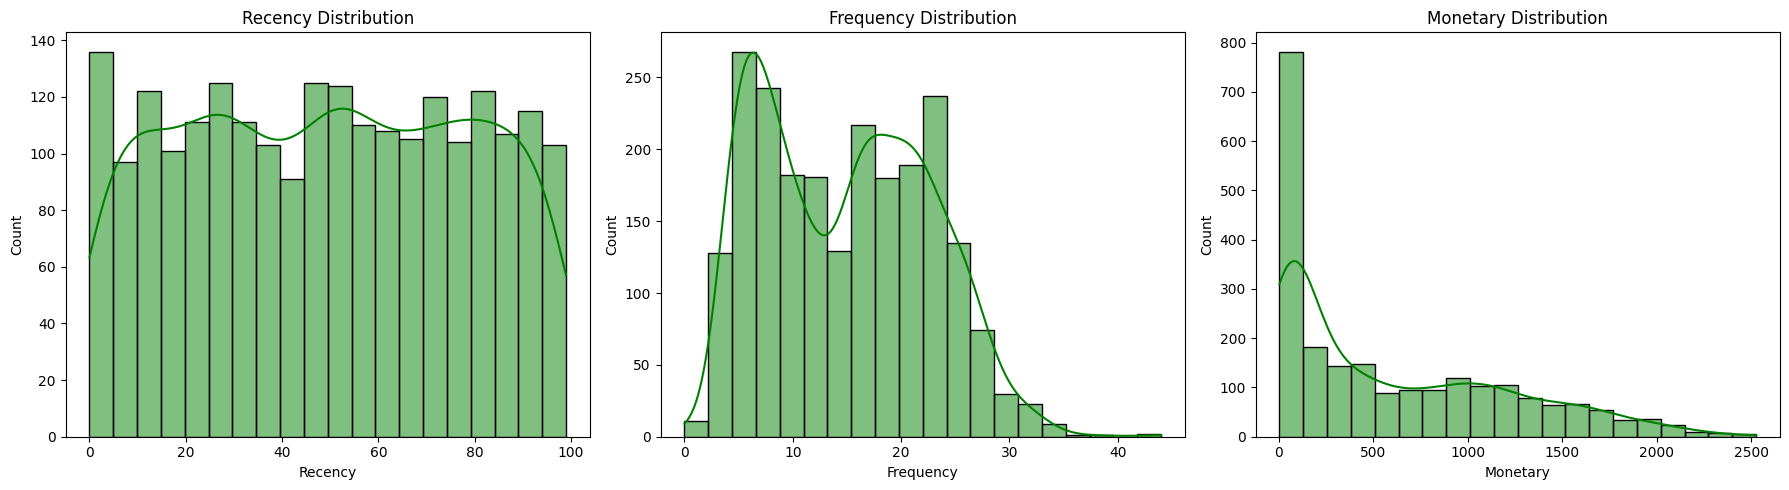

In [ ]:
# RFM Data Exporation 
# Recency: days since last purchase)                               
# Frequency: Total_Purchase (already have above)                                        
# Monetary: Total_Spend (already have above)

rfm = data[['ID', 'Recency', 'Total_Purchase', 'Total_Spend']].copy()
rfm.columns = ['ID', 'Recency', 'Frequency', 'Monetary']
rfm.describe().round(2)

# === RFM Distributions ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=20, kde=True, ax=axes[0], color='green')
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=20, kde=True, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()


In [25]:
# RFM Quartile Scoring 
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['M_Score'].astype(str)
rfm.head(10)

,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,5524,58,25,1617,2,4,4,244
1,2174,38,6,27,3,1,1,311
2,4141,26,21,776,3,3,3,333
3,6182,26,8,53,3,1,1,311
4,5324,94,19,422,1,3,3,133
5,7446,16,22,716,4,4,3,443
6,965,34,21,590,3,3,3,333
7,6177,32,10,169,3,2,2,322
8,4855,19,6,46,4,1,1,411
9,5899,68,2,49,2,1,1,211


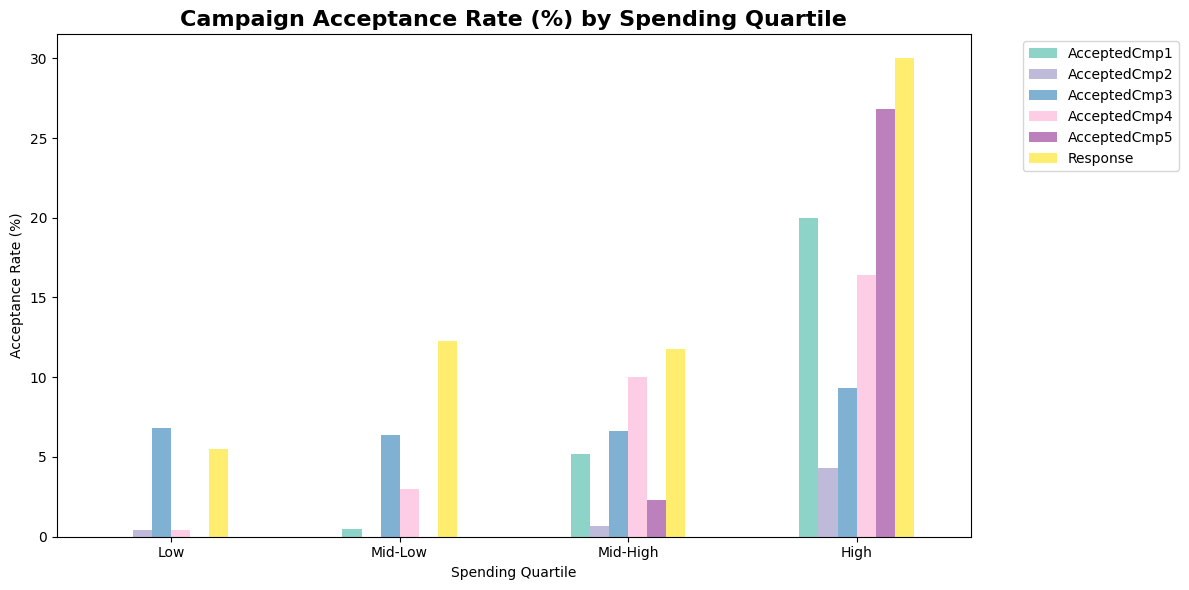

In [26]:
# Campaign Response Rate by Monetary Quartile
data['M_Quartile'] = pd.qcut(data['Total_Spend'].rank(method='first'), 4,
labels=['Low','Mid-Low','Mid-High','High'])

cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
response_by_spend = data.groupby('M_Quartile', observed=True)[cmp_cols].mean().round(3) * 100

response_by_spend.plot(kind='bar', figsize=(12, 6), colormap='Set3')
plt.title('Campaign Acceptance Rate (%) by Spending Quartile', fontsize=16, fontweight='bold')
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Spending Quartile')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



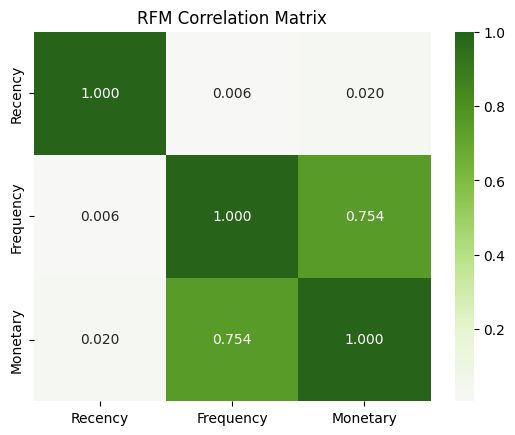

In [28]:
# RFM Correlation Matrix
rfm_corr = rfm[['Recency','Frequency','Monetary']].corr().round(3)
sns.heatmap(rfm_corr, annot=True, fmt=".3f", cmap="PiYG", center=0)
plt.title("RFM Correlation Matrix")
plt.show()

In [ ]:
# High and Low Value Customers
high_value = data[data['M_Quartile'] == 'High']
low_value = data[data['M_Quartile'] == 'Low']

print("=== HIGH VALUE (Top 25%) ===")
print(f"  Avg Income:       ${high_value['Income'].mean():,.0f}")
print(f"  Avg Purchases:    {high_value['Total_Purchase'].mean():.1f}")
print(f"  Avg Recency:      {high_value['Recency'].mean():.0f} days")
print(f"  Campaign Response: {high_value['Response'].mean()*100:.1f}%")
print()
print("=== LOW VALUE (Bottom 25%) ===")
print(f"  Avg Income:       ${low_value['Income'].mean():,.0f}")
print(f"  Avg Purchases:    {low_value['Total_Purchase'].mean():.1f}")
print(f"  Avg Recency:      {low_value['Recency'].mean():.0f} days")
print(f"  Campaign Response: {low_value['Response'].mean()*100:.1f}%")


=== HIGH VALUE (Top 25%) ===
  Avg Income:       $75,238
  Avg Purchases:    21.9
  Avg Recency:      50 days
  Campaign Response: 30.0%

=== LOW VALUE (Bottom 25%) ===
  Avg Income:       $32,351
  Avg Purchases:    6.0
  Avg Recency:      49 days
  Campaign Response: 5.5%
